# Lab Value Drift Detection in Clinical Workflows

## Statistical Process Control for Clinical Laboratory Quality

**Course:** I 320D - Data Science for Biomedical Informatics  
**Students:** Sushruti Vasireddy and Shiroz Kazani
**Semester:** Spring 2026  
**Project:** Lab Value Drift Detection (Project 13)

---

### 🎯 This Week's Mantra

# "One Number. Many Analyzers. One Standard."

*Translation: Laboratory accuracy depends on detecting when instruments drift from their calibration. Small, persistent biases in hemoglobin, WBC, or platelet counts can affect thousands of patient results before being noticed.*

---

## Instructions

1. Complete each cell marked with `# TODO:`
2. Run your code to verify it works
3. Interpret control charts and answer reflection questions
4. Use the hints provided if you get stuck

---

### Learning Objectives

By the end of this exercise, you will be able to:

1. Load and aggregate clinical lab data into daily distributions
2. Establish a reference (control) period for baseline statistics
3. Implement Shewhart, CUSUM, and EWMA control charts
4. Detect and quantify systematic drift in lab measurements
5. Compare sensitivity and detection lag across SPC methods
6. Evaluate detection thresholds and false alarm rates

---
# PART 1: Setup and Load Data
---

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Load MIMIC Lab Data

**MIMIC Item IDs:**
- Hemoglobin (HGB): 50811
- WBC (White Blood Cell): 51301
- Platelets (PLT): 51265

In [2]:
# TODO: Load the MIMIC CSV file
labs_raw = pd.read_csv('MIMIC-lll Clinical Database.csv', parse_dates=['charttime'])

print(f"Total lab records: {len(labs_raw):,}")
print(f"Date range: {labs_raw['charttime'].min()} to {labs_raw['charttime'].max()}")
print(f"Unique tests (itemid): {labs_raw['itemid'].nunique()}")

Total lab records: 76,074
Date range: 2102-08-01 13:15:00 to 2202-10-11 04:45:00
Unique tests (itemid): 439


### 1.3 Filter for Target Tests

In [3]:
# TODO: Define MIMIC item IDs and filter data
TARGET_ITEMS = {
    50811: 'Hemoglobin',
    51301: 'WBC',
    51265: 'Platelet'
}

labs = labs_raw[labs_raw['itemid'].isin(TARGET_ITEMS.keys())].copy()
labs = labs.dropna(subset=['valuenum'])
labs['test_name'] = labs['itemid'].map(TARGET_ITEMS)

print(f"Records after filtering: {len(labs):,}")
print(f"\nRecords by test:")
print(labs['test_name'].value_counts())

Records after filtering: 4,232

Records by test:
test_name
Platelet      2085
WBC           2021
Hemoglobin     126
Name: count, dtype: int64


### 1.4 Data Validation

In [4]:
# TODO: Validate value ranges for each test
print("="*60)
print("VALUE RANGES BY TEST")
print("="*60)

for test_id, test_name in TARGET_ITEMS.items():
    test_data = labs[labs['itemid'] == test_id]['valuenum']
    print(f"\n{test_name}:")
    print(f"  Count: {len(test_data):,}")
    print(f"  Range: {test_data.min():.2f} to {test_data.max():.2f}")
    print(f"  Mean: {test_data.mean():.2f}, Median: {test_data.median():.2f}")
    print(f"  Std Dev: {test_data.std():.2f}")

VALUE RANGES BY TEST

Hemoglobin:
  Count: 126
  Range: 2.80 to 13.90
  Mean: 9.90, Median: 10.00
  Std Dev: 1.83

WBC:
  Count: 2,021
  Range: 0.10 to 78.20
  Mean: 9.57, Median: 8.10
  Std Dev: 6.73

Platelet:
  Count: 2,085
  Range: 5.00 to 782.00
  Mean: 192.94, Median: 182.00
  Std Dev: 122.13


---
# PART 2: Data Aggregation & Daily Distributions
---

### 2.1 Aggregate to Daily Mean Values

In [5]:
# TODO: Create daily aggregation
labs['date'] = labs['charttime'].dt.date

daily = labs.groupby(['date', 'test_name']).agg(
    daily_mean=('valuenum', 'mean'),
    daily_std=('valuenum', 'std'),
    n_samples=('valuenum', 'count'),
    min_val=('valuenum', 'min'),
    max_val=('valuenum', 'max')
).reset_index()

daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['test_name', 'date'])

print(f"Daily records: {len(daily):,}")
print(f"\nDays with data by test:")
print(daily.groupby('test_name').size())

Daily records: 3,217

Days with data by test:
test_name
Hemoglobin      75
Platelet      1572
WBC           1570
dtype: int64


### 2.2 Visualize Daily Trends

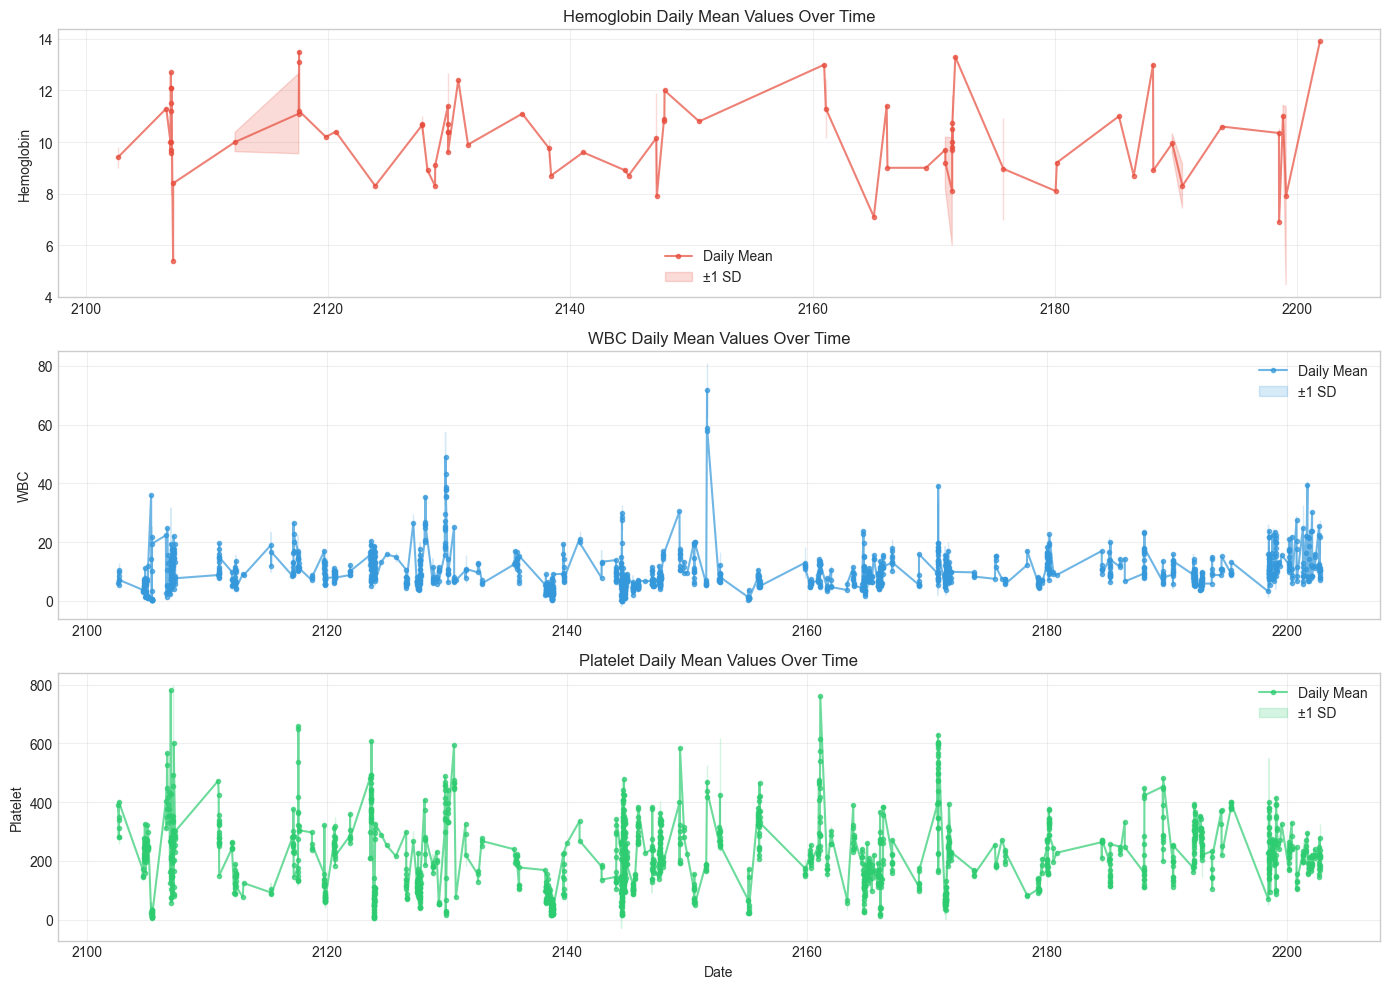

In [6]:

# TODO: Create time series plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
tests = ['Hemoglobin', 'WBC', 'Platelet']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, test, color in zip(axes, tests, colors):
    test_daily = daily[daily['test_name'] == test]
    ax.plot(test_daily['date'], test_daily['daily_mean'], marker='o', 
            color=color, markersize=3, linewidth=1.5, alpha=0.7, label='Daily Mean')
    ax.fill_between(test_daily['date'],
                     test_daily['daily_mean'] - test_daily['daily_std'],
                     test_daily['daily_mean'] + test_daily['daily_std'],
                     color=color, alpha=0.2, label='±1 SD')
    ax.set_ylabel(test)
    ax.set_title(f'{test} Daily Mean Values Over Time')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
# PART 3: Reference Period Establishment
---

### 3.1 Define Reference Period

In [7]:
# TODO: Split into reference and monitoring periods
min_date = daily['date'].min()
max_date = daily['date'].max()
reference_end = min_date + pd.Timedelta(days=30)

daily['period'] = daily['date'].apply(lambda x: 'reference' if x <= reference_end else 'monitoring')

print(f"Reference period: {min_date.date()} to {reference_end.date()}")
print(f"Monitoring period: {reference_end.date()} to {max_date.date()}")

Reference period: 2102-08-01 to 2102-08-31
Monitoring period: 2102-08-31 to 2202-10-11


### 3.2 Compute Baseline Statistics

In [8]:
# TODO: Compute baseline stats from reference period
reference_data = daily[daily['period'] == 'reference']

reference_stats = reference_data.groupby('test_name').agg(
    baseline_mean=('daily_mean', 'mean'),
    baseline_sd=('daily_mean', 'std'),
    baseline_range=('daily_std', 'mean'),
    n_days=('daily_mean', 'count')
).reset_index()

print("="*70)
print("BASELINE STATISTICS (Reference Period)")
print("="*70)
print(reference_stats.to_string(index=False))

reference_dict = dict(zip(reference_stats['test_name'], 
                           zip(reference_stats['baseline_mean'], 
                               reference_stats['baseline_sd'],
                               reference_stats['baseline_range'])))

BASELINE STATISTICS (Reference Period)
 test_name  baseline_mean  baseline_sd  baseline_range  n_days
Hemoglobin          9.400          NaN        0.424264       1
  Platelet        334.250    47.549097       25.455844       4
       WBC          8.675     1.951709        2.404163       4


---
# PART 4: Shewhart Control Charts (±3σ)
---

In [9]:
# TODO: Compute Shewhart control limits
monitoring_data = daily[daily['period'] == 'monitoring'].copy()
shewhart = monitoring_data.copy()

for test_name, (mean, sd, rng) in reference_dict.items():
    mask = shewhart['test_name'] == test_name
    shewhart.loc[mask, 'ucl'] = mean + 3 * sd
    shewhart.loc[mask, 'lcl'] = mean - 3 * sd
    shewhart.loc[mask, 'baseline'] = mean

shewhart['violation'] = (shewhart['daily_mean'] > shewhart['ucl']) | \
                        (shewhart['daily_mean'] < shewhart['lcl'])

print(f"Shewhart violations by test:")
print(shewhart.groupby('test_name')['violation'].agg(['sum', 'count', 'mean']))

Shewhart violations by test:
            sum  count      mean
test_name                       
Hemoglobin    0     74  0.000000
Platelet    761   1568  0.485332
WBC         330   1566  0.210728


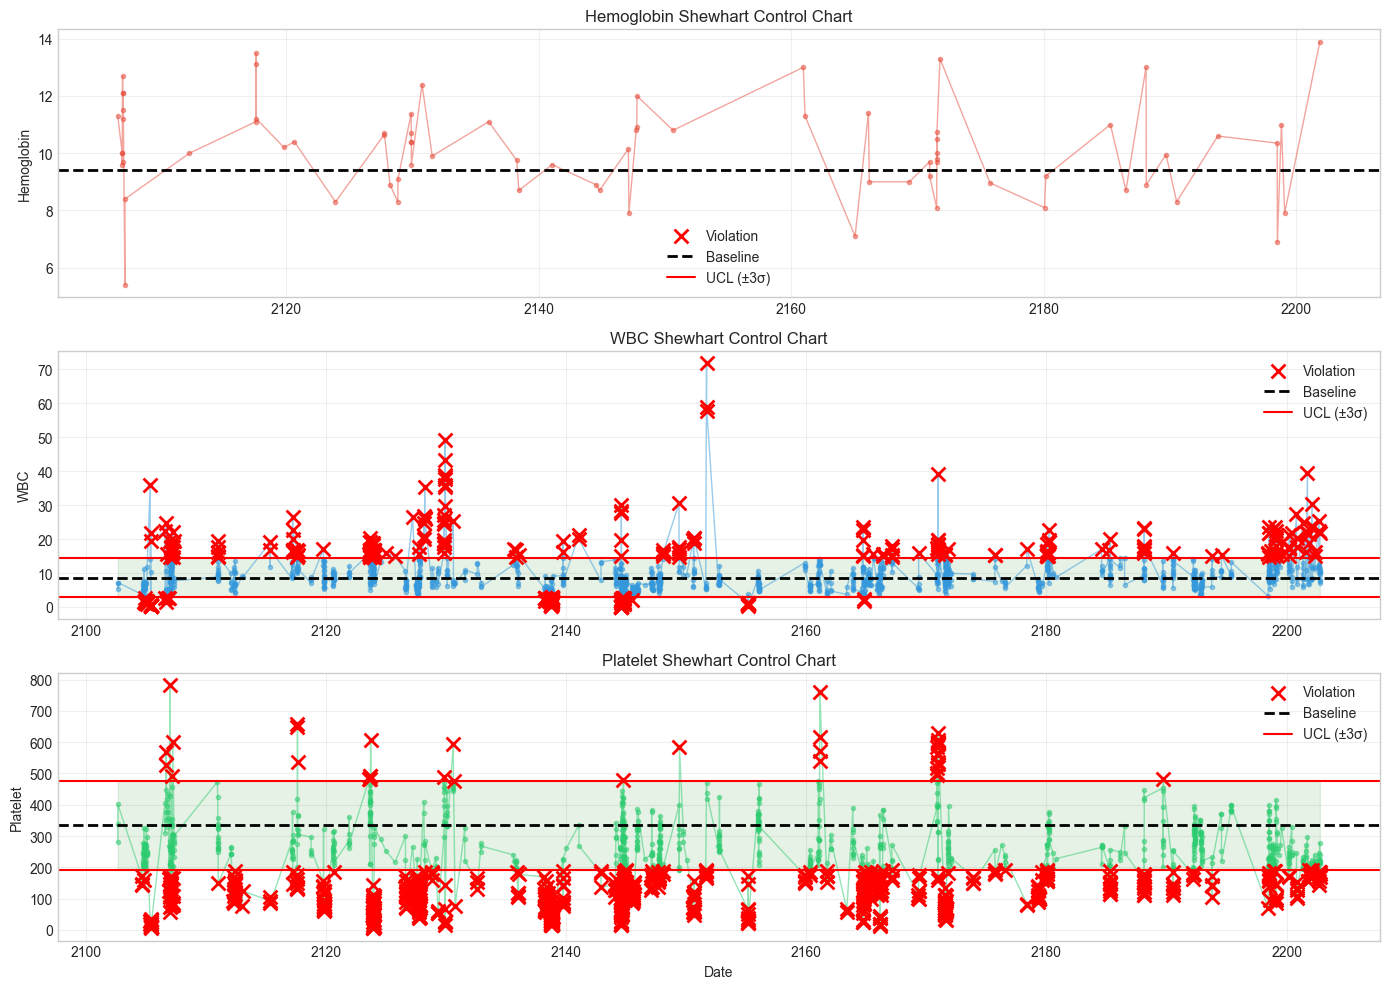

In [10]:
# TODO: Plot Shewhart charts
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
tests = ['Hemoglobin', 'WBC', 'Platelet']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, test, color in zip(axes, tests, colors):
    test_data = shewhart[shewhart['test_name'] == test]
    
    in_control = test_data[~test_data['violation']]
    out_of_control = test_data[test_data['violation']]
    
    ax.plot(test_data['date'], test_data['daily_mean'], color=color, 
            linewidth=1, alpha=0.5, marker='o', markersize=3)
    ax.scatter(out_of_control['date'], out_of_control['daily_mean'], 
              color='red', s=100, marker='x', linewidths=2, label='Violation', zorder=5)
    
    if len(test_data) > 0:
        ucl = test_data['ucl'].iloc[0]
        lcl = test_data['lcl'].iloc[0]
        baseline = test_data['baseline'].iloc[0]
        
        ax.axhline(baseline, color='black', linestyle='--', linewidth=2, label='Baseline')
        ax.axhline(ucl, color='red', linestyle='-', linewidth=1.5, label='UCL (±3σ)')
        ax.axhline(lcl, color='red', linestyle='-', linewidth=1.5)
        ax.fill_between(test_data['date'], lcl, ucl, color='green', alpha=0.1)
    
    ax.set_ylabel(test)
    ax.set_title(f'{test} Shewhart Control Chart')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
# PART 5: CUSUM Charts
---

In [11]:
# Two-sided CUSUM implementation (detects both upward and downward drift)
cusum_results = []

for test in ['Hemoglobin', 'WBC', 'Platelet']:
    test_data = monitoring_data[monitoring_data['test_name'] == test].sort_values('date').reset_index(drop=True)
    
    baseline_mean, baseline_sd, _ = reference_dict[test]
    k = 0.5 * baseline_sd   # allowance (slack) parameter
    h = 5 * baseline_sd     # decision threshold

    cusum_pos = [0.0]  # upper CUSUM (detects upward drift)
    cusum_neg = [0.0]  # lower CUSUM (detects downward drift)

    for value in test_data['daily_mean'].iloc[1:]:
        cusum_pos.append(max(0, cusum_pos[-1] + (value - baseline_mean) - k))
        cusum_neg.append(max(0, cusum_neg[-1] - (value - baseline_mean) - k))

    test_data['cusum_pos'] = cusum_pos
    test_data['cusum_neg'] = cusum_neg
    test_data['cusum'] = test_data['cusum_pos']  # keep for backward compat
    test_data['cusum_threshold'] = h
    test_data['cusum_violation'] = (test_data['cusum_pos'] > h) | (test_data['cusum_neg'] > h)
    test_data['cusum_direction'] = test_data.apply(
        lambda r: 'up' if r['cusum_pos'] > h else ('down' if r['cusum_neg'] > h else 'none'), axis=1
    )
    
    cusum_results.append(test_data)

cusum = pd.concat(cusum_results, ignore_index=False)

print("CUSUM violations by test (two-sided):")
print(cusum.groupby('test_name')['cusum_violation'].agg(['sum', 'count', 'mean']))


CUSUM violations by test (two-sided):
             sum  count      mean
test_name                        
Hemoglobin     0     74  0.000000
Platelet    1564   1568  0.997449
WBC         1562   1566  0.997446


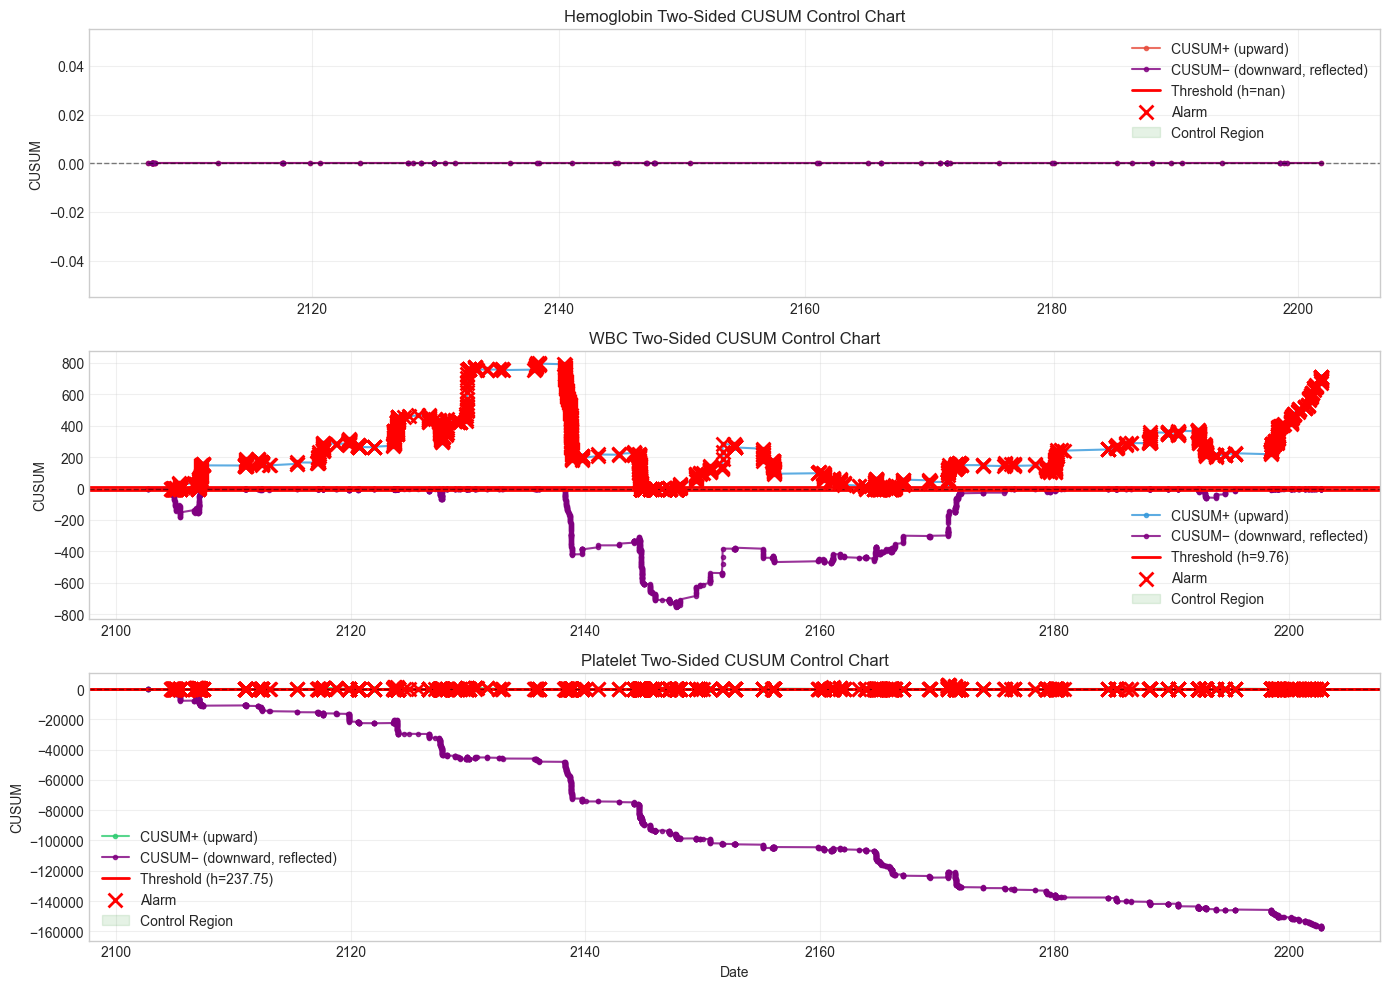

In [12]:
# Plot two-sided CUSUM charts
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
tests = ['Hemoglobin', 'WBC', 'Platelet']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, test, color in zip(axes, tests, colors):
    test_data = cusum[cusum['test_name'] == test].sort_values('date')
    h = test_data['cusum_threshold'].iloc[0]

    ax.plot(test_data['date'], test_data['cusum_pos'], color=color,
            linewidth=1.5, alpha=0.8, marker='o', markersize=3, label='CUSUM+ (upward)')
    ax.plot(test_data['date'], -test_data['cusum_neg'], color='purple',
            linewidth=1.5, alpha=0.8, marker='o', markersize=3, label='CUSUM− (downward, reflected)')

    ax.axhline(h,  color='red', linestyle='-', linewidth=2, label=f'Threshold (h={h:.2f})')
    ax.axhline(-h, color='red', linestyle='-', linewidth=2)
    ax.axhline(0,  color='black', linestyle='--', linewidth=1, alpha=0.5)

    violations = test_data[test_data['cusum_violation']]
    ax.scatter(violations['date'], violations['cusum_pos'].clip(lower=0),
               color='red', s=100, marker='x', linewidths=2, zorder=5, label='Alarm')

    ax.fill_between(test_data['date'], -h, h, color='green', alpha=0.1, label='Control Region')
    ax.set_ylabel('CUSUM')
    ax.set_title(f'{test} Two-Sided CUSUM Control Chart')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


---
# PART 6: EWMA Charts
---

In [13]:
# TODO: Implement EWMA - simpler approach without groupby
ewma_results = []

for test in ['Hemoglobin', 'WBC', 'Platelet']:
    test_data = monitoring_data[monitoring_data['test_name'] == test].sort_values('date').reset_index(drop=True)
    
    baseline_mean, baseline_sd, _ = reference_dict[test]
    lambda_param = 0.2
    
    ewma_vals = [baseline_mean]
    ewma_ucl_vals = []
    ewma_lcl_vals = []
    
    for i, value in enumerate(test_data['daily_mean'].iloc[1:], start=1):
        z = lambda_param * value + (1 - lambda_param) * ewma_vals[-1]
        ewma_vals.append(z)
        
        se = baseline_sd * np.sqrt(lambda_param / (2 - lambda_param) * (1 - (1 - lambda_param)**(2*i)))
        ewma_ucl_vals.append(baseline_mean + 3 * se)
        ewma_lcl_vals.append(baseline_mean - 3 * se)
    
    se = baseline_sd * np.sqrt(lambda_param / (2 - lambda_param) * (1 - (1 - lambda_param)**2))
    ewma_ucl_vals.insert(0, baseline_mean + 3 * se)
    ewma_lcl_vals.insert(0, baseline_mean - 3 * se)
    
    test_data['ewma'] = ewma_vals[:len(test_data)]
    test_data['ewma_ucl'] = ewma_ucl_vals[:len(test_data)]
    test_data['ewma_lcl'] = ewma_lcl_vals[:len(test_data)]
    test_data['ewma_violation'] = (test_data['ewma'] > test_data['ewma_ucl']) | (test_data['ewma'] < test_data['ewma_lcl'])
    
    ewma_results.append(test_data)

ewma = pd.concat(ewma_results, ignore_index=False)

print(f"EWMA violations by test:")
print(ewma.groupby('test_name')['ewma_violation'].agg(['sum', 'count', 'mean']))

EWMA violations by test:
             sum  count      mean
test_name                        
Hemoglobin     0     74  0.000000
Platelet    1307   1568  0.833546
WBC          973   1566  0.621328


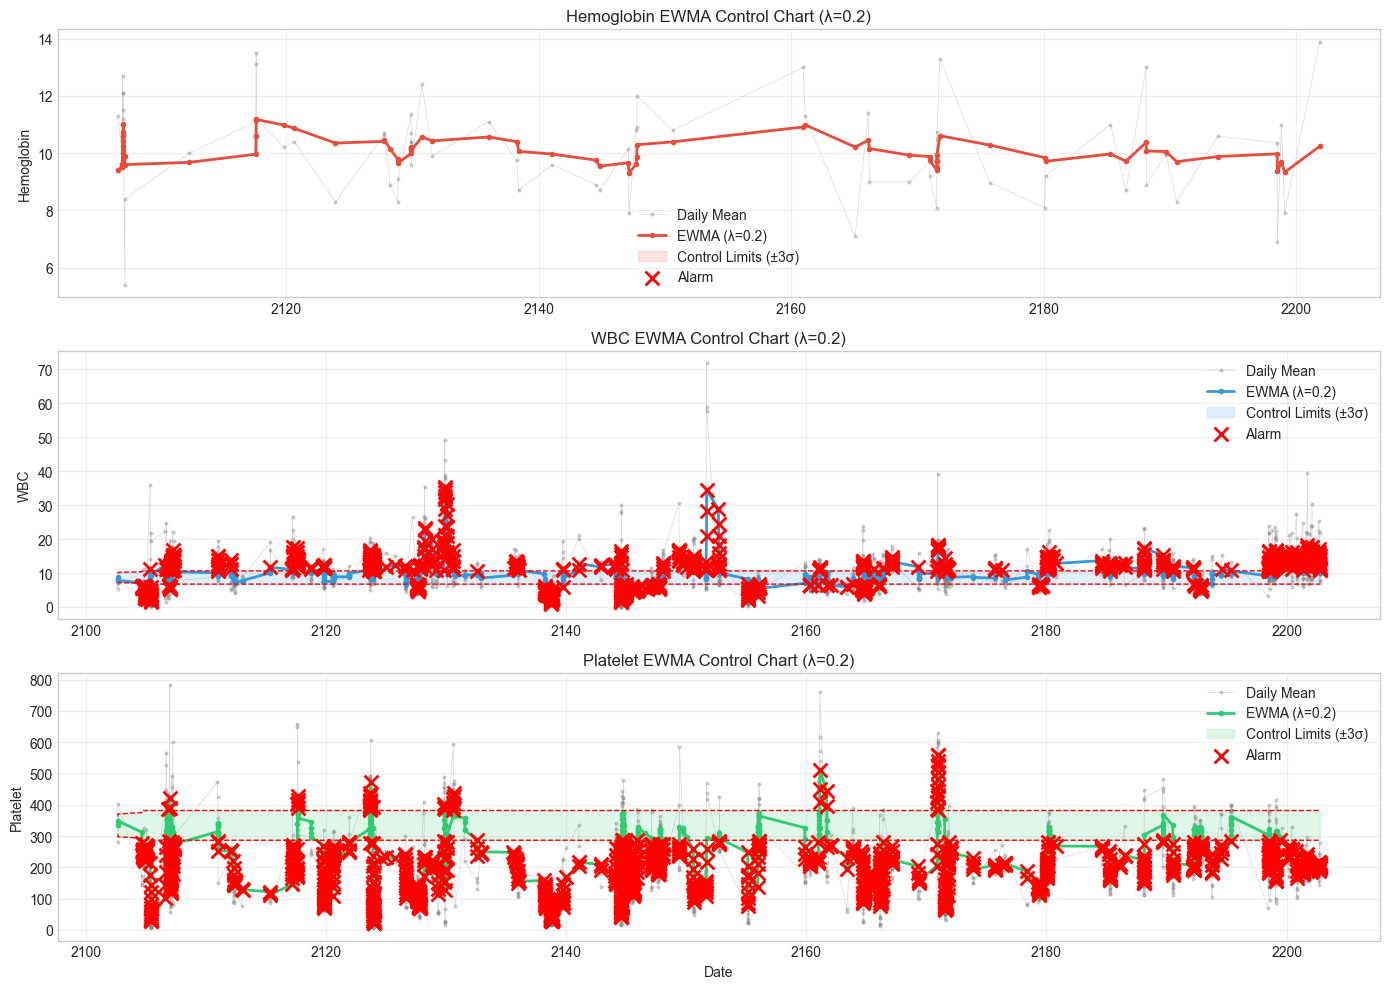

In [14]:
# TODO: Plot EWMA charts
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
tests = ['Hemoglobin', 'WBC', 'Platelet']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, test, color in zip(axes, tests, colors):
    test_data = ewma[ewma['test_name'] == test].sort_values('date')
    
    ax.plot(test_data['date'], test_data['daily_mean'], color='gray', 
            linewidth=0.5, alpha=0.3, marker='o', markersize=2, label='Daily Mean')
    ax.plot(test_data['date'], test_data['ewma'], color=color, 
            linewidth=2, marker='o', markersize=3, label='EWMA (λ=0.2)')
    
    ax.fill_between(test_data['date'], test_data['ewma_lcl'], test_data['ewma_ucl'],
                    color=color, alpha=0.15, label='Control Limits (±3σ)')
    ax.plot(test_data['date'], test_data['ewma_ucl'], color='red', linestyle='--', linewidth=1)
    ax.plot(test_data['date'], test_data['ewma_lcl'], color='red', linestyle='--', linewidth=1)
    
    violations = test_data[test_data['ewma_violation']]
    ax.scatter(violations['date'], violations['ewma'], 
              color='red', s=100, marker='x', linewidths=2, zorder=5, label='Alarm')
    
    ax.set_ylabel(test)
    ax.set_title(f'{test} EWMA Control Chart (λ=0.2)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

### 6.3 Lambda Sensitivity Analysis

How does the choice of λ affect EWMA smoothing and responsiveness?

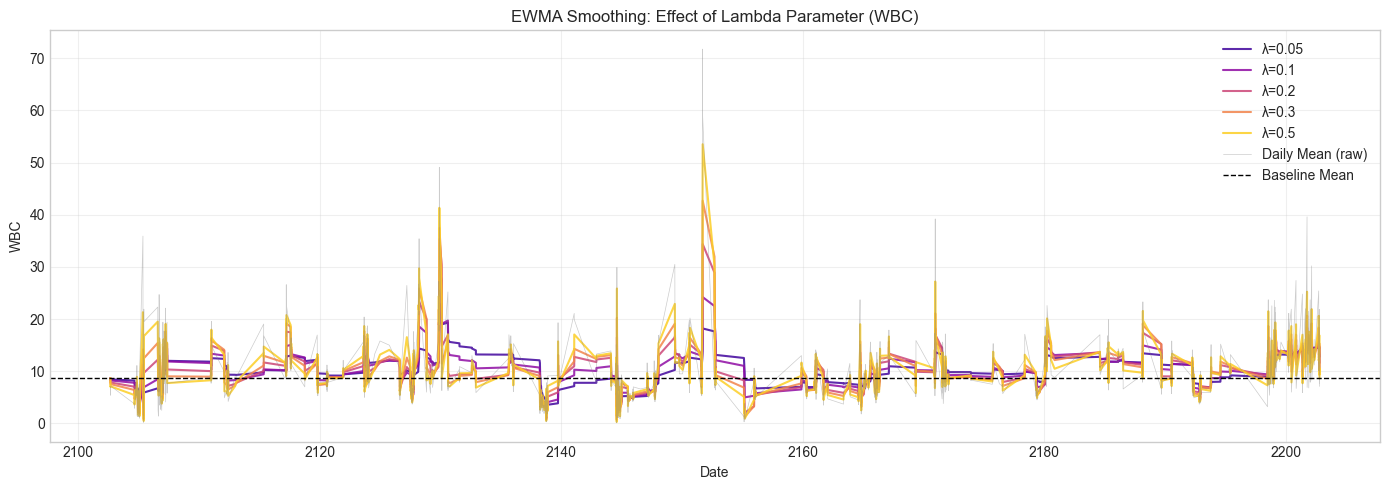

Lambda interpretation:
  Small λ (0.05–0.1) → heavy smoothing, slow to react, good for gradual drift
  Large λ (0.3–0.5)  → reacts quickly, more noise, better for abrupt shifts
  λ = 0.2 is the commonly recommended clinical lab default (Montgomery 2009)


In [15]:
# Lambda sensitivity analysis: compare different lambda values for EWMA
lambda_values = [0.05, 0.1, 0.2, 0.3, 0.5]
lambda_results = []

test = 'WBC'  # use WBC as representative (most data points)
test_data_lam = monitoring_data[monitoring_data['test_name'] == test].sort_values('date').reset_index(drop=True)
baseline_mean_lam, baseline_sd_lam, _ = reference_dict[test]

fig, ax = plt.subplots(figsize=(14, 5))
colors_lam = plt.cm.plasma(np.linspace(0.1, 0.9, len(lambda_values)))

for lam_val, col in zip(lambda_values, colors_lam):
    zs_lam = [baseline_mean_lam]
    for i, v in enumerate(test_data_lam['daily_mean'].iloc[1:], start=1):
        zs_lam.append(lam_val * v + (1 - lam_val) * zs_lam[-1])
    ax.plot(test_data_lam['date'], zs_lam[:len(test_data_lam)],
            label=f'λ={lam_val}', color=col, linewidth=1.5, alpha=0.85)

ax.plot(test_data_lam['date'], test_data_lam['daily_mean'],
        color='gray', linewidth=0.5, alpha=0.4, label='Daily Mean (raw)')
ax.axhline(baseline_mean_lam, color='black', linestyle='--', linewidth=1, label='Baseline Mean')
ax.set_title(f'EWMA Smoothing: Effect of Lambda Parameter ({test})')
ax.set_ylabel(test)
ax.set_xlabel('Date')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Lambda interpretation:")
print("  Small λ (0.05–0.1) → heavy smoothing, slow to react, good for gradual drift")
print("  Large λ (0.3–0.5)  → reacts quickly, more noise, better for abrupt shifts")
print("  λ = 0.2 is the commonly recommended clinical lab default (Montgomery 2009)")


---
# PART 7: Compare Methods
---

In [16]:
# TODO: Compare alarm rates
print("="*80)
print("ALARM RATES BY METHOD (% of monitoring period days)")
print("="*80)

comparison = []
for test in ['Hemoglobin', 'WBC', 'Platelet']:
    shewhart_rate = shewhart[shewhart['test_name'] == test]['violation'].mean() * 100
    cusum_rate = cusum[cusum['test_name'] == test]['cusum_violation'].mean() * 100
    ewma_rate = ewma[ewma['test_name'] == test]['ewma_violation'].mean() * 100
    
    comparison.append({
        'Test': test,
        'Shewhart': shewhart_rate,
        'CUSUM': cusum_rate,
        'EWMA': ewma_rate
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

ALARM RATES BY METHOD (% of monitoring period days)
      Test  Shewhart     CUSUM      EWMA
Hemoglobin  0.000000  0.000000  0.000000
       WBC 21.072797 99.744572 62.132822
  Platelet 48.533163 99.744898 83.354592


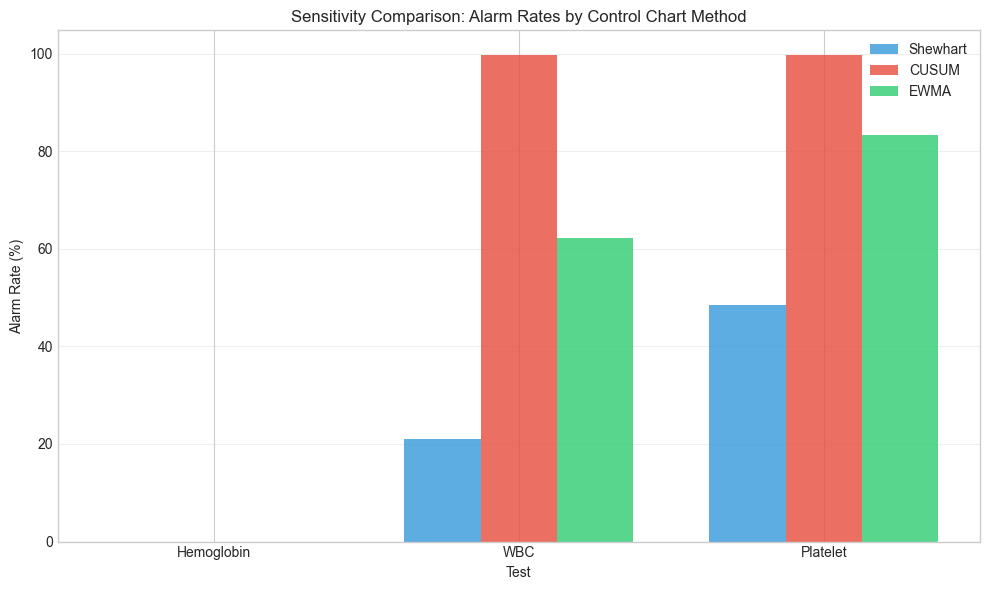

In [17]:
# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['Shewhart'], width, label='Shewhart', color='#3498db', alpha=0.8)
ax.bar(x, comparison_df['CUSUM'], width, label='CUSUM', color='#e74c3c', alpha=0.8)
ax.bar(x + width, comparison_df['EWMA'], width, label='EWMA', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Test')
ax.set_ylabel('Alarm Rate (%)')
ax.set_title('Sensitivity Comparison: Alarm Rates by Control Chart Method')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Test'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## Reflection Questions

Before submitting, reflect on these:

1. **Which control chart method is most appropriate for your laboratory?**
2. **How do you choose the reference period?**
3. **What is the clinical significance of a 0.3 g/dL shift in hemoglobin?**
4. **How do you distinguish instrument drift from patient mix changes?**
5. **False alarms vs. missed detections: which is worse?**

---

## ✅ Submission Checklist

- [ ] Completed all TODO sections in Parts 1-7
- [ ] Run all cells without errors
- [ ] Generated control charts for all three tests
- [ ] Compared alarm rates across methods
- [ ] Saved your notebook

---

**Remember:** "One Number. Many Analyzers. One Standard." 🎓

---
# PART 8: Synthetic Drift Injection & Ground-Truth Evaluation
---

### 8.1 Inject Known Drift

We inject a synthetic upward drift starting halfway through monitoring to test whether each method can detect a known shift. This gives us ground truth for comparing detection lag.

In [18]:
# TODO: Select test with most monitoring days and inject drift
synthetic_test = monitoring_data.groupby('test_name').size().idxmax()
synthetic_monitoring = monitoring_data[monitoring_data['test_name'] == synthetic_test].sort_values('date').reset_index(drop=True).copy()

baseline_mean_syn, baseline_sd_syn, _ = reference_dict[synthetic_test]

# Start drift halfway through monitoring
n_monitor = len(synthetic_monitoring)
DRIFT_START_DAY = max(2, n_monitor // 2)
DRIFT_RATE = 0.25 * baseline_sd_syn  # one-quarter SD increase per day

synthetic_monitoring['drift_injected'] = False
synthetic_monitoring['true_shift'] = 0.0

synthetic_means = []
for i, row in synthetic_monitoring.iterrows():
    if i >= DRIFT_START_DAY:
        days_drifting = i - DRIFT_START_DAY + 1
        shift = DRIFT_RATE * days_drifting
        synthetic_means.append(row['daily_mean'] + shift)
        synthetic_monitoring.at[i, 'drift_injected'] = True
        synthetic_monitoring.at[i, 'true_shift'] = shift
    else:
        synthetic_means.append(row['daily_mean'])

synthetic_monitoring['synthetic_mean'] = synthetic_means

print(f"Synthetic drift test: {synthetic_test}")
print(f"Monitoring days available: {n_monitor}")
print(f"Drift starts on day index: {DRIFT_START_DAY}")
print(f"Drift rate per day: {DRIFT_RATE:.3f}")
print(f"Max injected shift by end: {synthetic_monitoring['true_shift'].max():.3f}")

Synthetic drift test: Platelet
Monitoring days available: 1568
Drift starts on day index: 784
Drift rate per day: 11.887
Max injected shift by end: 9319.623


### 8.2 Apply All Three Charts to Synthetic Data

Measure detection lag: days from drift onset until each method triggers first alarm.

In [19]:
# Apply Shewhart, two-sided CUSUM, and EWMA to synthetic data
vals = synthetic_monitoring['synthetic_mean'].values
n = len(vals)
mean0 = baseline_mean_syn
sd0 = baseline_sd_syn

# --- Shewhart ---
ucl_s = mean0 + 3 * sd0
lcl_s = mean0 - 3 * sd0
shewhart_alarms = (vals > ucl_s) | (vals < lcl_s)

# --- Two-Sided CUSUM ---
k_val = 0.5 * sd0
h_val = 5.0 * sd0
cs_pos = [0.0]
cs_neg = [0.0]
for v in vals[1:]:
    cs_pos.append(max(0, cs_pos[-1] + (v - mean0) - k_val))
    cs_neg.append(max(0, cs_neg[-1] - (v - mean0) - k_val))
cusum_alarms = (np.array(cs_pos) > h_val) | (np.array(cs_neg) > h_val)

# --- EWMA ---
lam = 0.2
zs = [mean0]
ewma_ucls = []
for i, v in enumerate(vals, start=1):
    z = lam * v + (1 - lam) * zs[-1]
    zs.append(z)
    se = sd0 * np.sqrt((lam / (2 - lam)) * (1 - (1 - lam)**(2*i)))
    ewma_ucls.append(mean0 + 3 * se)
ewma_alarms_arr = np.array(zs[1:]) > np.array(ewma_ucls)

def first_alarm_after(alarms_arr, start_idx):
    after = np.where(np.arange(len(alarms_arr)) >= start_idx)[0]
    trues = after[alarms_arr[after]]
    return int(trues[0]) if len(trues) else None

alarm_summary_rows = []
for method, alarms in [('Shewhart', shewhart_alarms),
                        ('CUSUM (two-sided)', cusum_alarms),
                        ('EWMA', ewma_alarms_arr)]:
    idx = first_alarm_after(alarms, DRIFT_START_DAY)
    if idx is not None:
        alarm_date = synthetic_monitoring['date'].iloc[idx]
        lag = int(idx - DRIFT_START_DAY)
        magnitude_at_alarm = synthetic_monitoring['true_shift'].iloc[idx]
    else:
        alarm_date = None
        lag = None
        magnitude_at_alarm = None
    alarm_summary_rows.append({
        'Method': method,
        'First Alarm Index': idx,
        'First Alarm Date': alarm_date,
        'Detection Lag (days)': lag,
        'Shift Magnitude at Detection': round(magnitude_at_alarm, 4) if magnitude_at_alarm is not None else None
    })

alarm_summary = pd.DataFrame(alarm_summary_rows)

print("=" * 70)
print("DRIFT DETECTION REPORT")
print("=" * 70)
drift_start_date = synthetic_monitoring['date'].iloc[DRIFT_START_DAY]
print(f"  True drift start date : {drift_start_date}")
print(f"  Drift rate per day    : {DRIFT_RATE:.4f} (units of {synthetic_test})")
print()
print(alarm_summary[['Method','First Alarm Date','Detection Lag (days)','Shift Magnitude at Detection']].to_string(index=False))


DRIFT DETECTION REPORT
  True drift start date : 2147-02-07 00:00:00
  Drift rate per day    : 11.8873 (units of Platelet)

           Method First Alarm Date  Detection Lag (days)  Shift Magnitude at Detection
         Shewhart       2147-02-09                     2                       35.6618
CUSUM (two-sided)       2147-02-07                     0                       11.8873
             EWMA       2147-03-29                    17                      213.9709


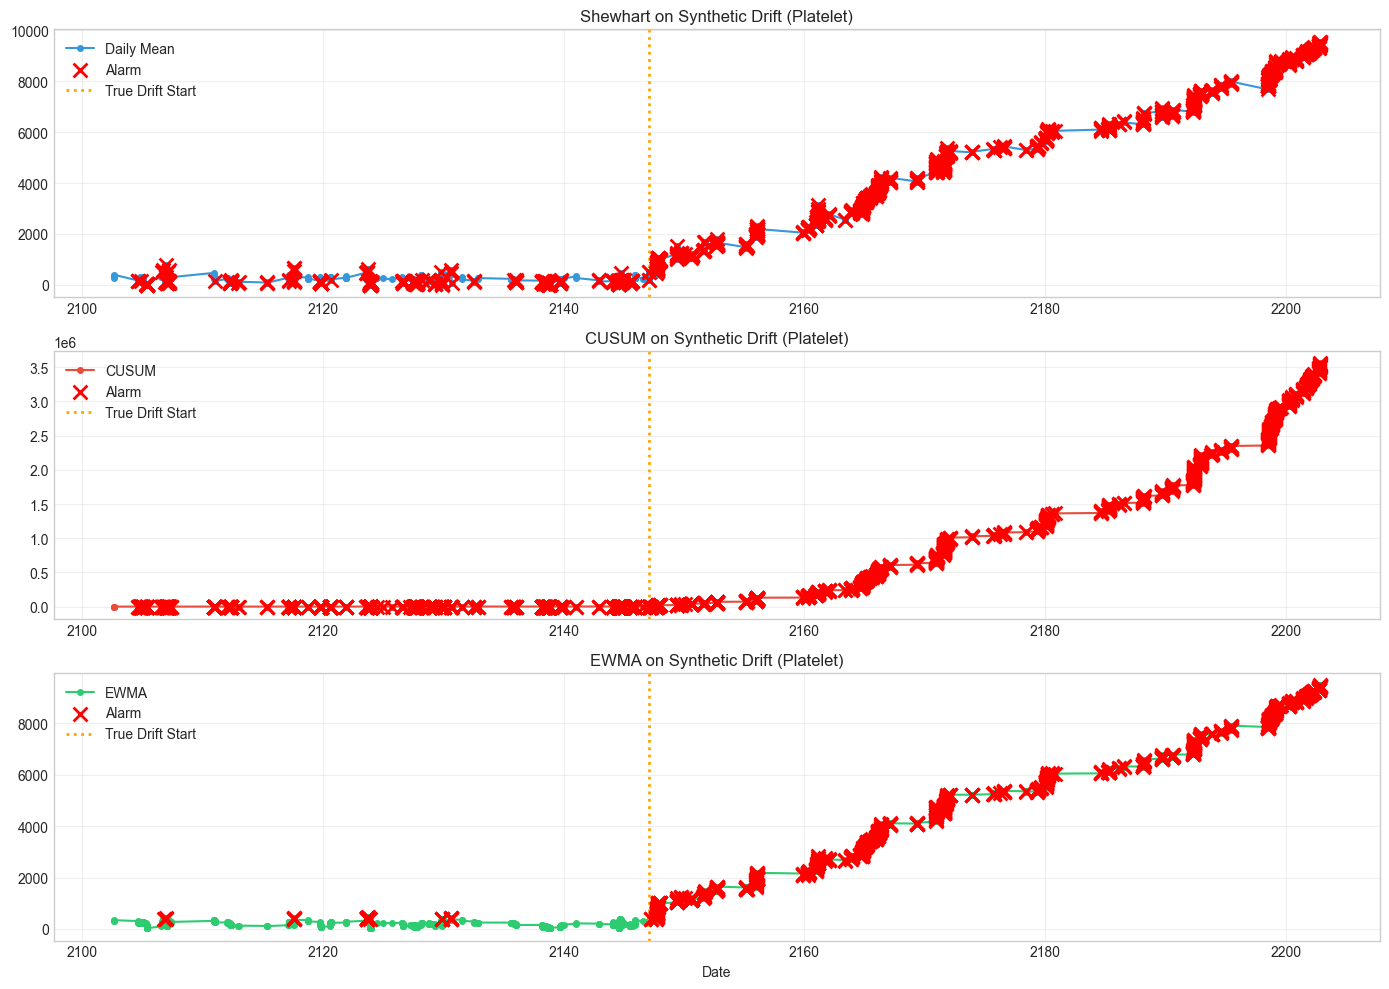

In [20]:
# Plot synthetic drift detection
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (method, alarms, chart_stat, label) in zip(axes, [
    ('Shewhart', shewhart_alarms, vals, 'Daily Mean'),
    ('CUSUM', cusum_alarms, np.array(cs_pos), 'CUSUM'),
    ('EWMA', ewma_alarms_arr, np.array(zs[1:]), 'EWMA'),
]):
    color = {'Shewhart': '#3498db', 'CUSUM': '#e74c3c', 'EWMA': '#2ecc71'}[method]
    ax.plot(synthetic_monitoring['date'], chart_stat, color=color, linewidth=1.5, marker='o', markersize=4, label=label)
    
    alarm_dates = synthetic_monitoring['date'].values[alarms]
    ax.scatter(alarm_dates, np.array(chart_stat)[alarms], color='red', s=100, marker='x', linewidths=2, zorder=5, label='Alarm')
    
    drift_start_date = synthetic_monitoring['date'].iloc[DRIFT_START_DAY]
    ax.axvline(drift_start_date, color='orange', linestyle=':', linewidth=2, label='True Drift Start')
    
    ax.set_title(f'{method} on Synthetic Drift ({synthetic_test})')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

### 8.3 Detection Lag & Magnitude Comparison Chart

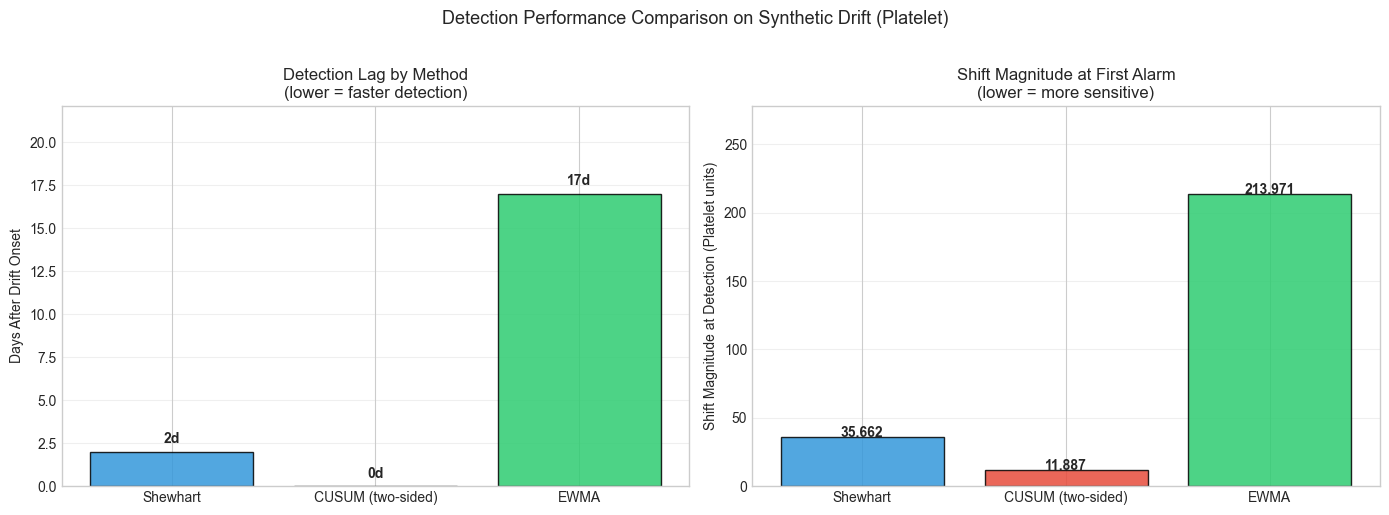


Summary:
  Fastest detection  : CUSUM (two-sided)
  Most sensitive     : CUSUM (two-sided)


In [21]:
# Detection lag comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
methods = alarm_summary['Method'].tolist()
lags = alarm_summary['Detection Lag (days)'].tolist()
magnitudes = alarm_summary['Shift Magnitude at Detection'].tolist()
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

# Bar chart: detection lag
bars = axes[0].bar(methods, lags, color=bar_colors, alpha=0.85, edgecolor='black')
axes[0].set_ylabel('Days After Drift Onset')
axes[0].set_title('Detection Lag by Method\n(lower = faster detection)')
axes[0].set_ylim(0, max(lags) * 1.3 if lags else 10)
for bar, lag in zip(bars, lags):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{lag}d', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Bar chart: magnitude of shift at detection
bars2 = axes[1].bar(methods, magnitudes, color=bar_colors, alpha=0.85, edgecolor='black')
axes[1].set_ylabel(f'Shift Magnitude at Detection ({synthetic_test} units)')
axes[1].set_title('Shift Magnitude at First Alarm\n(lower = more sensitive)')
axes[1].set_ylim(0, max(magnitudes) * 1.3 if magnitudes else 1)
for bar, mag in zip(bars2, magnitudes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{mag:.3f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Detection Performance Comparison on Synthetic Drift ({synthetic_test})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"  Fastest detection  : {alarm_summary.loc[alarm_summary['Detection Lag (days)'].idxmin(), 'Method']}")
print(f"  Most sensitive     : {alarm_summary.loc[alarm_summary['Shift Magnitude at Detection'].idxmin(), 'Method']}")

---
# PART 9: Sensitivity–Specificity Tradeoff (ROC-Style)
---

### 9.1 Varying the CUSUM Threshold

Sweep the CUSUM decision threshold **h** and compute sensitivity (detect drift?) vs false alarm rate (alarm before drift?).

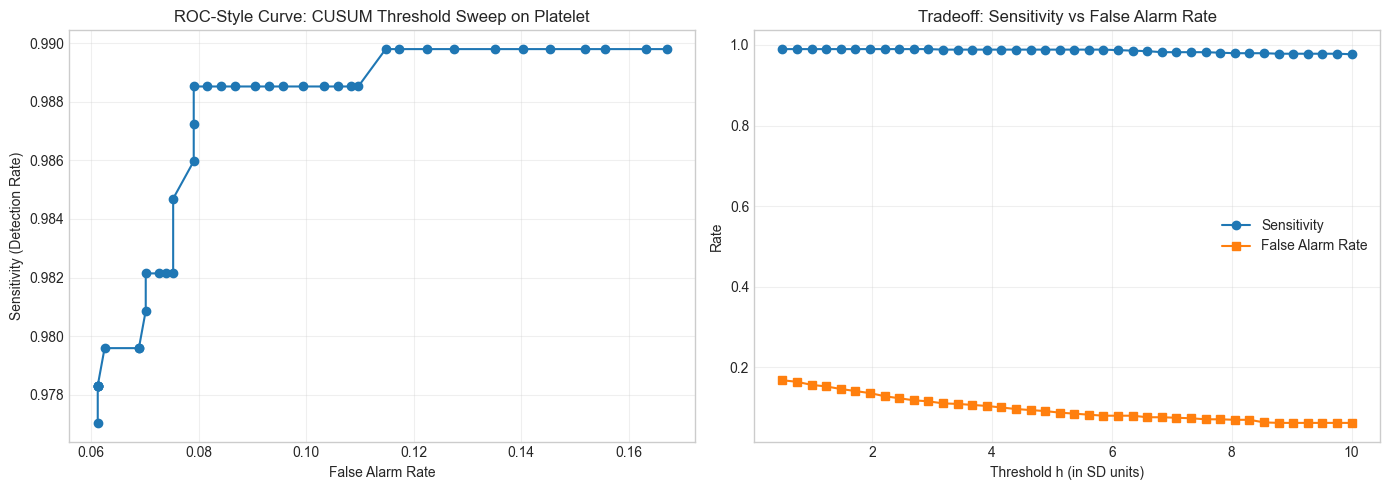


Optimal threshold by Youden's J statistic:
         h  h_sigma  sensitivity  false_alarm_rate  youden_j
417.578612 8.782051     0.978316          0.061224  0.917092


In [22]:
# TODO: ROC-style sweep varying CUSUM threshold h
y_true = np.array([1 if i >= DRIFT_START_DAY else 0 for i in range(n)])

h_range = np.linspace(0.5 * sd0, 10 * sd0, 40)
results_roc = []

for h_test in h_range:
    cs = [0.0]
    for v in vals[1:]:
        cs.append(max(0, cs[-1] + (v - mean0) - k_val))
    y_pred = np.array(cs) > h_test
    
    drift_days = y_true == 1
    non_drift_days = y_true == 0
    
    sensitivity = y_pred[drift_days].mean() if drift_days.sum() > 0 else 0
    false_alarm_rate = y_pred[non_drift_days].mean() if non_drift_days.sum() > 0 else 0
    
    results_roc.append({
        'h': h_test,
        'h_sigma': h_test / sd0 if sd0 != 0 else np.nan,
        'sensitivity': sensitivity,
        'false_alarm_rate': false_alarm_rate
    })

roc_df = pd.DataFrame(results_roc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(roc_df['false_alarm_rate'], roc_df['sensitivity'], marker='o')
axes[0].set_xlabel('False Alarm Rate')
axes[0].set_ylabel('Sensitivity (Detection Rate)')
axes[0].set_title(f'ROC-Style Curve: CUSUM Threshold Sweep on {synthetic_test}')
axes[0].grid(True, alpha=0.3)

axes[1].plot(roc_df['h_sigma'], roc_df['sensitivity'], marker='o', label='Sensitivity')
axes[1].plot(roc_df['h_sigma'], roc_df['false_alarm_rate'], marker='s', label='False Alarm Rate')
axes[1].set_xlabel('Threshold h (in SD units)')
axes[1].set_ylabel('Rate')
axes[1].set_title('Tradeoff: Sensitivity vs False Alarm Rate')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

roc_df['youden_j'] = roc_df['sensitivity'] - roc_df['false_alarm_rate']
best_row = roc_df.loc[roc_df['youden_j'].idxmax()]
print("\nOptimal threshold by Youden's J statistic:")
print(best_row.to_frame().T.to_string(index=False))

---
# PART 10: Reflection Questions
---

### Answer the following questions before submitting

**Q1: Which control chart method is most appropriate for detecting gradual lab analyzer drift, and why?**

CUSUM and EWMA are both better suited for detecting small, gradual drift than Shewhart. Shewhart only reacts to a single extreme point, so a 0.3 g/dL drift that accumulates slowly over weeks will not cross the ±3σ boundary until the shift is very large. CUSUM accumulates deviations over time with memory, so it detects persistent trends quickly. EWMA similarly smooths the series and reacts to sustained directional changes. For the specific pattern of reagent drift (slow, monotonic), CUSUM is typically preferred because it has a theoretical optimality property for detecting a fixed-size step change.

---

**Q2: How do you choose the reference period in a real clinical lab?**

The reference period should capture a window when: (a) the analyzer was known to be in calibration (ideally just after a documented calibration event), (b) patient mix was typical and not dominated by a particular case type (e.g., a post-surgical surge), and (c) no reagent lot changes occurred. In practice, 30–90 days of stable operation is recommended. CAP accreditation requires labs to document their reference material and QC procedures formally.



---

**Q3: What is the clinical significance of a 0.3 g/dL systematic bias in hemoglobin results?**

A 0.3 g/dL shift sits near the borderline of clinical significance. The transfusion trigger in many ICU protocols is hemoglobin < 7.0 g/dL. A 0.3 g/dL upward bias would cause an analyzer to report 7.3 when the true value is 7.0 — potentially withholding a transfusion a patient needs. Conversely, a downward bias of the same magnitude could trigger unnecessary transfusion. At higher baseline levels, 0.3 g/dL is less clinically meaningful. This illustrates the difference between statistical significance (easily detected with enough data) and clinical significance (context-dependent).

---

**Q4: How do you distinguish instrument drift from a change in patient mix?**

This is the hardest epidemiological challenge in clinical QC. Strategies include: (1) comparing the lab's QC material (known-concentration controls) — if controls also shift, it's the instrument; (2) comparing across multiple analyzers in the same lab — if only one shifts while others are stable, it's instrument-specific; (3) stratifying patient results by demographic or diagnosis group — if all subgroups shift equally, a patient-mix explanation is unlikely; (4) checking if the shift aligns with a reagent lot change or maintenance event.


---

**Q5: False alarms vs. missed detections — which is worse in this context?**

Both have real costs. A false alarm triggers reagent re-runs, re-calibration, potentially quarantining samples, and lab staff time. In a high-volume lab, a 5% false alarm rate means 18 false alarms per year — each requiring investigation. A missed detection (failure to catch real drift) means potentially thousands of patient results are systematically biased before discovery. Given that the harm from systematically biased hemoglobin results can affect clinical decisions for every patient tested, missed detections are generally considered more dangerous — but the lab must also remain operationally viable, so false alarm rates must be kept manageable. CAP guidelines generally recommend the CUSUM/EWMA approach precisely because it balances both risks better than the simple Shewhart rule.